In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from hopper import HopperEnv
from plots import traj_comparison
from dit_utils import State_Normalizer, set_seed, load_dataset
from dit_utils import closed_loop_stats, barplot_comparison
from DiT_SA import SA_ODE, SA_Planner
from projectors_SA import Reference_Projector, Admissible_Projector

In [2]:
# Hyperparameters

plot_height = False
device = "cpu"
H = 32 # prediction horizon
N_s0 = 16 # number of different initial states sampled to evaluate each model
N_samples = 8 # number of trajectories sampled pre initial state to evaluate each model
model_size = {"d_model": 128, "n_heads": 4, "depth": 4}
mode = "full"

In [3]:
# Normalizes states and concatenates them to actions

set_seed(0) 
env = HopperEnv() 
ID = InverseDynamics(env)
N_trajs = 1000
N_eval_trajs = 10 # number of trajectories to evaluate the models
obs, act = load_dataset(f"datasets/{mode}_{N_trajs}trajs_300steps")
obs = torch.FloatTensor(obs[:, :299]).to(device)
act = torch.FloatTensor(act[:, :299]).to(device)

normalizer = State_Normalizer(obs)
nor_obs = normalizer.normalize(obs)
x = torch.cat([nor_obs, act], dim=-1) # dataset of state-action trajectories
sigma_data = x.std().item()


Loading dataset datasets/full_1000trajs_300steps
Normalization vector has shape torch.Size([12])


In [14]:
# Diffusion Transformer without projections

ode = SA_ODE(env, sigma_data, device=device, N=5, **model_size, horizon=H)
assert ode.load(extra=f"_{mode}")
# assert ode.load(extra=f"_{mode}_finetuned")
planner = SA_Planner(env, ode, normalizer)


Initialized State Action ODE model with 1241103 parameters.
Loading trained/SA_ODE_Hopper__specs_128_4_4_h_32_full.pt


In [5]:
# Reference Projector without target

# ref_proj = Reference_Projector(env, normalizer, sigma_min=0.0021, sigma_max=0.2, target=False)
# proj_ode = SA_ODE(env, sigma_data, device=device, N=5, **model_size, projector=ref_proj)
# proj_ode.load(extra="_CL")
# proj_planner = SA_Planner(env, proj_ode, normalizer)


In [6]:
# Initial trajectory

traj_id = 1#0
true_traj = obs[traj_id]
s0 = true_traj[0].reshape(1, env.state_size)

No world model in Planner.best_traj.
 Using env instead to select best candidate (cheating)
0 longest survival: 0 + 15
0 longest survival: 16 + 15
0 longest survival: 32 + 15
0 longest survival: 48 + 15
0 longest survival: 64 + 15
0 longest survival: 80 + 0
Failure of trajectory 0 at timestep 81
Reward ['149.2']


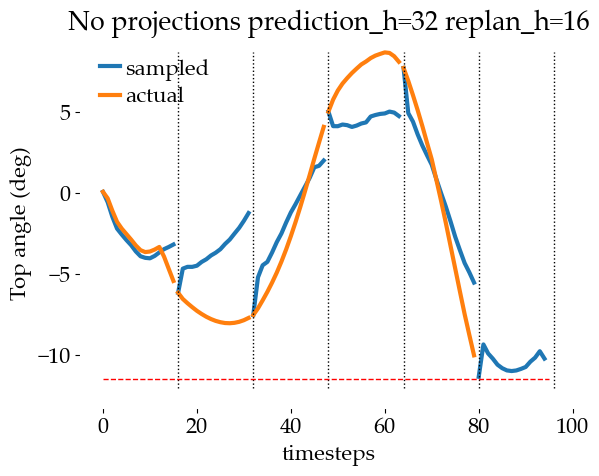

In [16]:
# DiT without projections

replan_horizon = H//2
# pred, actual, reward = planner.closed_loop_traj(s0, traj_len=300, replan_horizon=replan_horizon)
pred, actions, actual, reward = planner.best_traj(s0, traj_len=300, replan_horizon=replan_horizon, n_samples_per_s0=8)
pred = pred[0]
actual = actual[0]

traj_comparison(env, pred, "sampled", actual, "actual", horizon=replan_horizon,
                title=f"No projections prediction_h={H} replan_h={replan_horizon}", 
                plot_height=plot_height)

In [8]:
pred.shape, actual.shape

(torch.Size([288, 12]), (289, 12))

In [9]:
traj_pred, action_pred, actual_traj, Rewards = planner.best_traj(s0, traj_len=300, replan_horizon=replan_horizon,
                                                                  n_samples_per_s0=N_samples, projector=None)

# traj_comparison(env, true_traj, "true", traj[0], "sampled",
#                 traj_3=ID_traj, label_3="ID",
#                 traj_4=ol_traj, label_4="open-loop",
#                 title="Trained without projections", 
#                 plot_height=plot_height)


No world model in Planner.best_traj.
 Using env instead to select best candidate (cheating)
0 longest survival: 0 + 15
0 longest survival: 16 + 15
0 longest survival: 32 + 15
0 longest survival: 48 + 15
0 longest survival: 64 + 15
0 longest survival: 80 + 15
0 longest survival: 96 + 15
0 longest survival: 112 + 15
0 longest survival: 128 + 15
0 longest survival: 144 + 15
0 longest survival: 160 + 15
0 longest survival: 176 + 15
0 longest survival: 192 + 15
0 longest survival: 208 + 15
0 longest survival: 224 + 15
0 longest survival: 240 + 15
0 longest survival: 256 + 15
0 longest survival: 272 + 15
Reward ['816.0']


In [10]:
# mean_rwd, std_rwd, mean_survival, std_survival = open_loop_stats(env, planner, ID, N_s0=N_s0, H=H, N_samples=N_samples)
# labels.append("no proj")
# list_of_rewards.append(mean_rwd)
# list_of_rewards_std.append(std_rwd)
# list_of_survival.append(mean_survival)
# list_of_survival_std.append(std_survival)

# DiT without projections


# mean_rwd, std_rwd, mean_survival, std_survival = open_loop_stats(env, inference_planner, ID, N_s0=N_s0, H=H, N_samples=N_samples)
# labels.append("inference")
# list_of_rewards.append(mean_rwd)
# list_of_rewards_std.append(std_rwd)
# list_of_survival.append(mean_survival)
# list_of_survival_std.append(std_survival)

In [11]:
# Reference Projector

# proj_traj, proj_actions = proj_planner.best_traj(s0, traj_len=H, n_samples_per_s0=N_samples, projector=ref_proj)
# total_reward, survival, ol_proj_traj = open_loop(env, s0, proj_actions[0])
# print(f"Open-loop actions from DiT with Reference Projector, reward: {total_reward:.1f}  survival: {survival:.2f}")
# ID_proj_traj = ID.closest_admissible_traj(proj_traj[0])[0]
# print(f"proj_traj diverged at step {ID_proj_traj.shape[0]}")

# traj_comparison(env, true_traj, "true", proj_traj[0], "ref proj",
#                 traj_3=ID_proj_traj, label_3="ID",
#                 traj_4=ol_proj_traj, label_4="open-loop",
#                 title="Trained with Reference Projector", plot_height=plot_height)

# mean_rwd, std_rwd, mean_survival, std_survival = open_loop_stats(env, proj_planner, ID, N_s0=N_s0, H=H, N_samples=N_samples)
# labels.append("proj")
# list_of_rewards.append(mean_rwd)
# list_of_rewards_std.append(std_rwd)
# list_of_survival.append(mean_survival)
# list_of_survival_std.append(std_survival)


In [12]:
# Open-loop performance comparison


# barplot_comparison(labels, list_of_survival, list_of_rewards, list_of_survival_std,
#                     list_of_rewards_std, title="Hopper Closed-loop " + mode)
